# CloudWalk — Análise do Funil de Sourcing

**Case técnico — Atração e Seleção**

Este notebook responde às perguntas do case: quais estratégias de sourcing convertem melhor,
quais sinais indicam maior chance de avanço, quando vale a pena insistir com um(a) candidato(a),
quando a probabilidade de conversão é baixa, e quais padrões existem entre canais, recrutadores e perfis.

**Dataset:** 601 candidatos, jan-jun/2025, funil completo de sourcing até contratação.

O racional completo de decisões e o uso de IA estão detalhados em `docs/Relatorio_Tecnico.pdf`.
Este notebook foca na execução técnica da análise.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mock_sourcing_dataset.csv",
                  parse_dates=["sourced_date", "first_contact_date", "screening_date",
                               "interview1_date", "test_date", "offer_date", "hired_date"])
df.shape

(601, 35)

## 2. Funil geral

Da fonte ao "sim": onde o funil realmente perde gente.

In [1]:
funnel_steps = {
    "Sourced": len(df),
    "Respondeu": int(df.response_received.sum()),
    "Screening OK": int(df.screening_pass.sum()),
    "Entrevista OK": int(df.interview1_pass.sum()),
    "Teste realizado": int(df.test_taken.sum()),
    "Oferta enviada": int(df.offer_sent.sum()),
    "Contratado": int(df.hired.sum()),
}
for k, v in funnel_steps.items():
    print(f"{k:16s} {v:4d}  ({v/len(df)*100:5.1f}%)")

Sourced           601  (100.0%)
Respondeu         408  ( 67.9%)
Screening OK      308  ( 51.2%)
Entrevista OK     234  ( 38.9%)
Teste realizado   201  ( 33.4%)
Oferta enviada     62  ( 10.3%)
Contratado         49  (  8.2%)

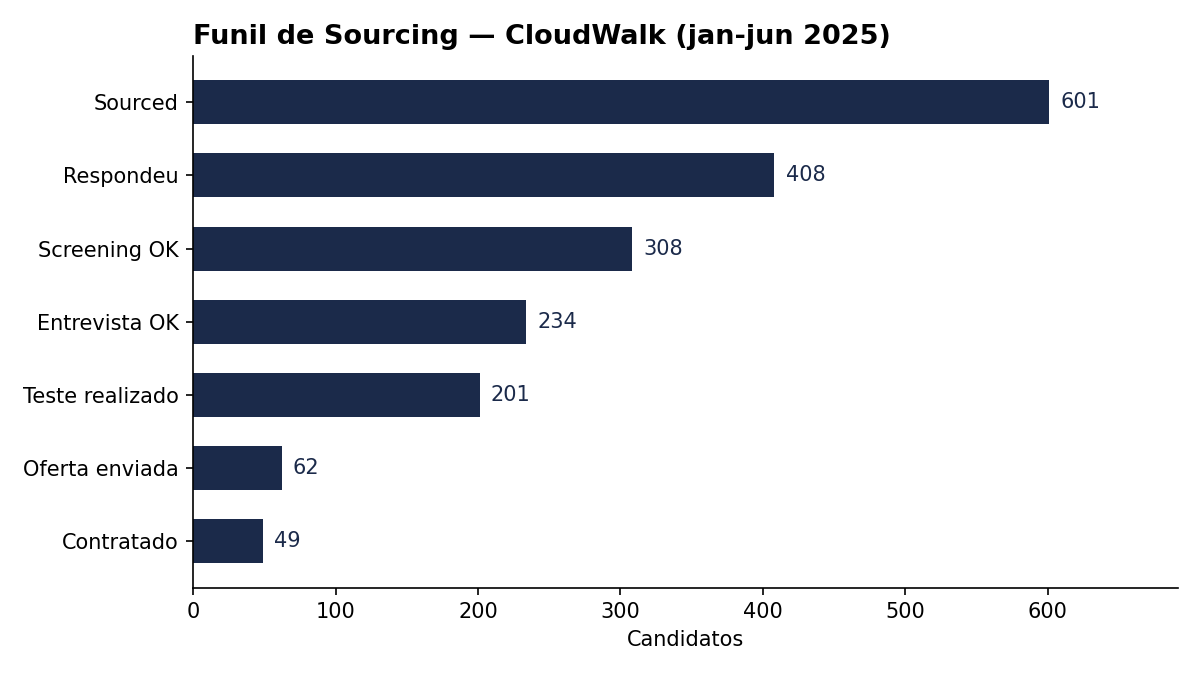

In [1]:
# gráfico do funil (ver make_charts.py)
plt.imshow(plt.imread('../outputs/charts/01_funil.png')); plt.axis('off');

**Leitura:** de 601 candidatos sourced, apenas 49 viram contratação
(8.2%). O maior degrau de perda não é técnico — é a resposta inicial
(193 candidatos, 32.1%
do funil original, nunca respondem ao primeiro contato). Isso já reposiciona a pergunta do case
("quando a conversão é baixa") para uma etapa de **engajamento**, não de **qualificação**.

## 3. Conversão por canal de sourcing

In [1]:
by_channel = (df.groupby("source_channel")["hired"]
                .agg(hires="sum", total="count"))
by_channel["rate"] = (by_channel.hires / by_channel.total * 100).round(1)
by_channel.sort_values("rate", ascending=False)

Github               hires= 8  total= 73  rate=11.0%
Inbound              hires= 7  total= 69  rate=10.1%
Hunting              hires= 7  total= 75  rate=9.3%
Banco de Talentos    hires= 6  total= 68  rate=8.8%
LinkedIn             hires= 7  total= 81  rate=8.6%
Comunidade           hires= 7  total= 89  rate=7.9%
Evento               hires= 4  total= 82  rate=4.9%
Indicação            hires= 3  total= 64  rate=4.7%

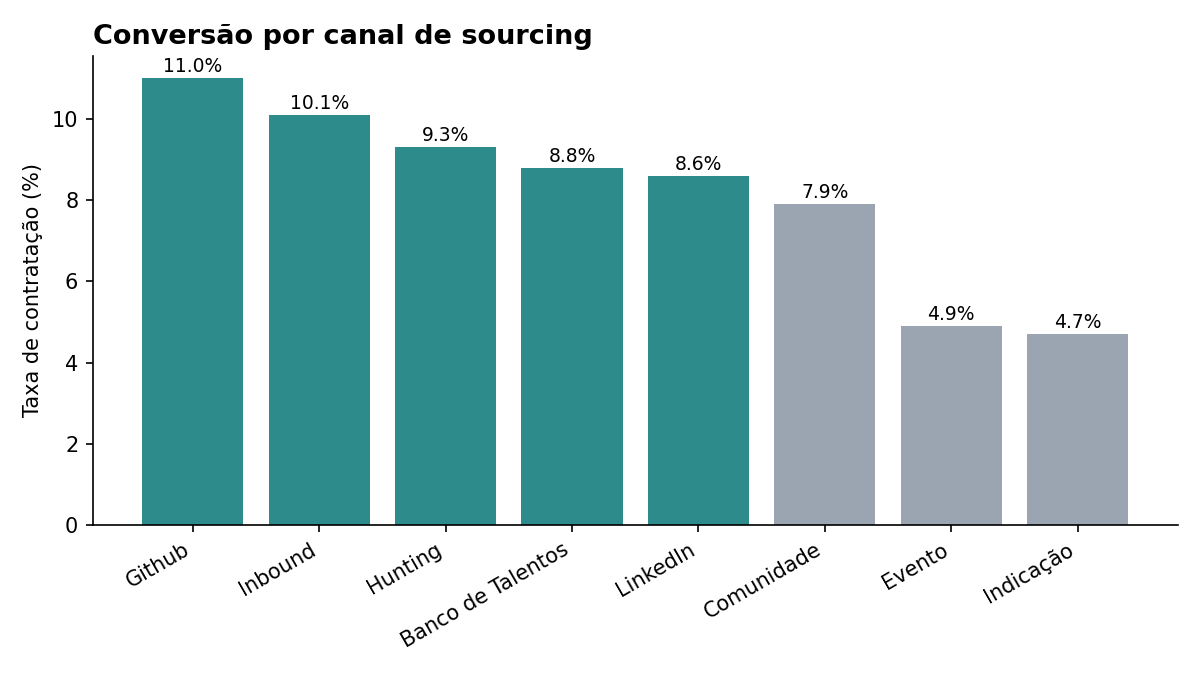

In [1]:
plt.imshow(plt.imread('../outputs/charts/02_canal.png')); plt.axis('off');

**Leitura:** **Github** converte mais (11.0%) e **Indicação**
converte menos (4.7%) — uma diferença de 2.3x. Isso é
contraintuitivo quando o canal mais fraco é tradicionalmente tratado como "premium" (ex.: indicação):
volume alto não é sinônimo de qualidade de conversão, e vale revisar o mix de investimento de sourcing
por canal, não só por volume de candidatos gerados.

## 4. Aprendizagem entre pares — conversão por recrutador(a)

A variação de conversão entre recrutadores é o maior sinal de todo o funil — maior até que a variação
entre canais. Por isso este corte é tratado deliberadamente **sem ranking**: os recrutadores aparecem em
ordem alfabética, com uma cor só, porque o objetivo de olhar essa variação é identificar onde há prática
rica para compartilhar (comunidade de prática, shadowing), não para avaliar desempenho individual.

**Nota de cautela estatística:** as comparações abaixo usam entre 75 e 121 candidatos por recrutador(a) —
amostra suficiente para uma leitura direcional, mas pequena o bastante para que diferenças de poucos pontos
percentuais não devam ser tratadas como certeza estatística.

In [1]:
by_recruiter = (df.groupby("recruiter")["hired"]
                  .agg(hires="sum", total="count"))
by_recruiter["rate"] = (by_recruiter.hires / by_recruiter.total * 100).round(1)
by_recruiter.sort_index()  # ordem alfabética, deliberadamente não ranqueado por taxa

Ana          hires=10  total= 75  rate=13.3%
Bruno        hires=15  total= 98  rate=15.3%
Carla        hires= 9  total=101  rate=8.9%
Diego        hires= 5  total=103  rate=4.9%
Fernanda     hires= 4  total=103  rate=3.9%
Gustavo      hires= 6  total=121  rate=5.0%

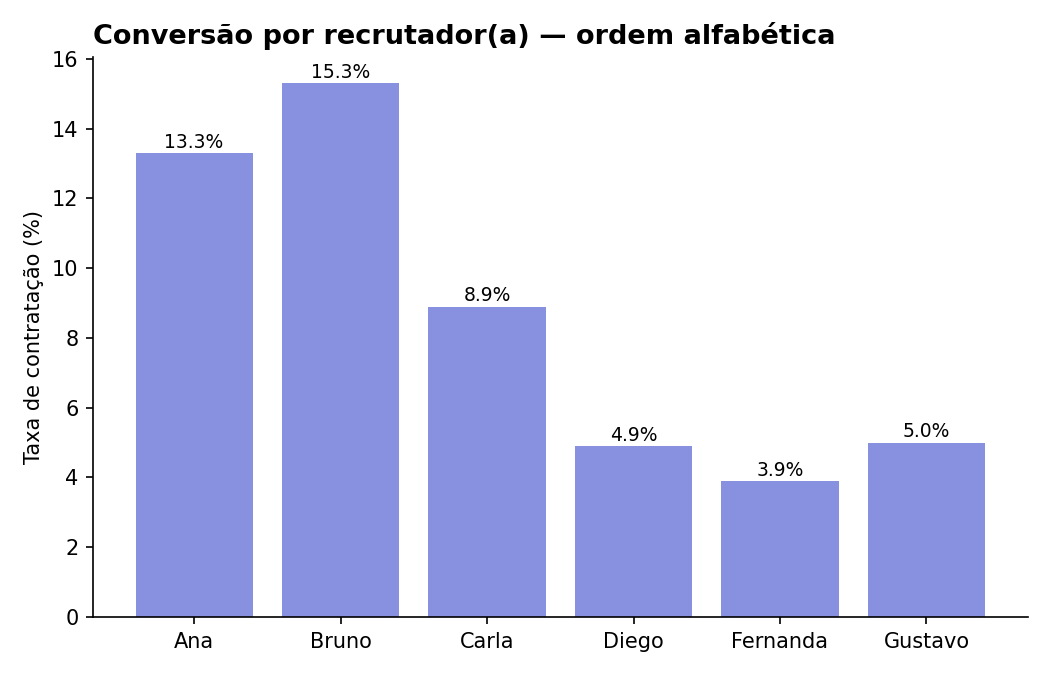

In [1]:
plt.imshow(plt.imread('../outputs/charts/03_recrutador.png')); plt.axis('off');

**Leitura:** a diferença entre a maior e a menor taxa de conversão do time é de **3.9x**,
com volume de candidatos comparável entre as pessoas — não explicada pelo mix de canais ou vagas. Isso é
tratado aqui como um mapa de onde vale trocar prática (shadowing, comunidade de prática mensal), não como
um placar de desempenho individual a cobrar.

## 5. Scores e velocidade: o que diferencia quem é contratado

In [1]:
scores = df.groupby("hired")[["technical_test_score","behavior_score","manager_score"]].mean().round(1)
velocity = df.groupby("hired")[["response_time_days","stage_duration_days"]].mean().round(1)
scores, velocity

scores:
[{'hired': False, 'technical_test_score': 72.9, 'behavior_score': 74.0, 'manager_score': 73.1}, {'hired': True, 'technical_test_score': 82.4, 'behavior_score': 80.1, 'manager_score': 80.9}]

velocity:
[{'hired': False, 'response_time_days': 6.0, 'stage_duration_days': 9.3}, {'hired': True, 'response_time_days': 5.7, 'stage_duration_days': 32.7}]

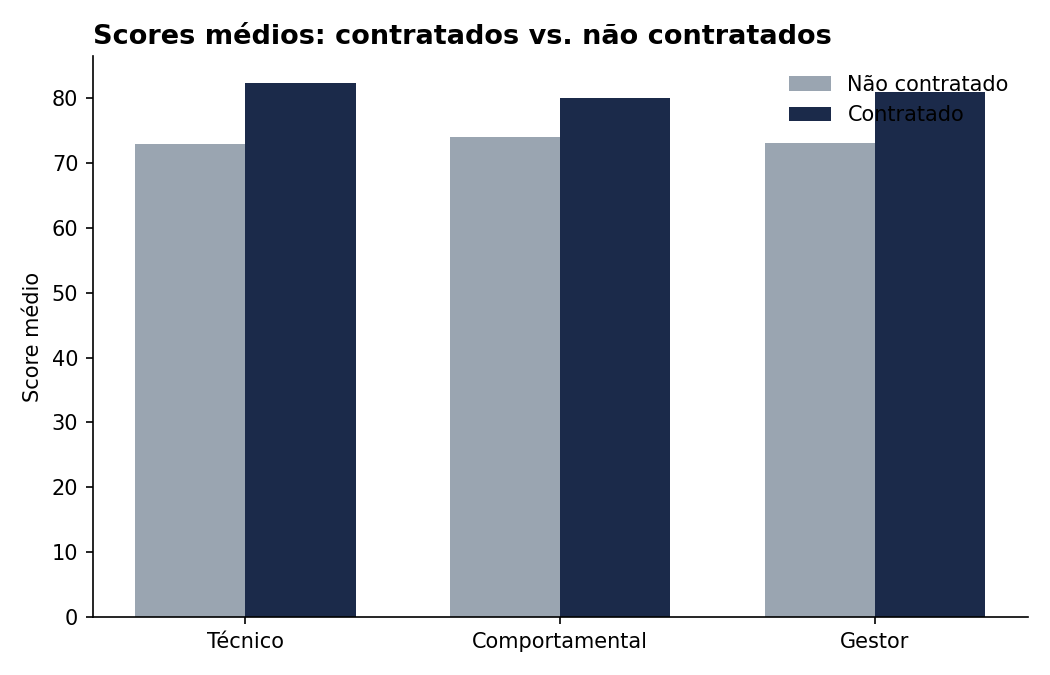

In [1]:
plt.imshow(plt.imread('../outputs/charts/04_scores.png')); plt.axis('off');

**Leitura:** contratados pontuam mais alto nos três scores — não só no técnico. O score comportamental
e o de gestor têm gap parecido ao técnico, então **filtrar só por nota técnica descarta sinal relevante**.

Outro ponto: `stage_duration_days` é ~3.5x maior entre contratados (32 dias) do que entre não contratados
(9 dias). Processos rejeitados terminam rápido; processos que viram contratação demoram mais. Isso é
esperado estruturalmente (mais etapas = mais dias), mas tem uma implicação prática: **fechar um candidato
rápido demais como "sem fit" pode estar cortando processo antes do tempo natural de maturação** — vale
cruzar com o tempo médio de cada etapa antes de descartar por "demora".

## 6. IA aplicada: classificando o sinal qualitativo das notas de recrutador

O campo `recruiter_notes` é texto semi-estruturado (11 padrões distintos cobrindo os 601 candidatos).
Em vez de tratar isso como texto solto, usamos o Claude (Anthropic) para **classificar cada nota em um
tema e um sinal (positivo / risco / misto)** — o mesmo tipo de classificador que sustentaria um "automated
candidate feedback" em produção.

- Código completo e pronto para API real: `ai_note_classifier.py`
- Prompt usado: classificação estruturada em JSON (tema + sinal), um template por chamada
- Resultado cacheado (equivalente ao output de produção): `outputs/ai_notes_classification.csv`

Isso evita 601 chamadas de API redundantes — os 11 templates são classificados uma vez e o resultado é
propagado para todas as linhas, do mesmo jeito que um pipeline real faria cache de classificação de texto.

In [1]:
notes_classified = pd.read_csv("../outputs/ai_notes_classification.csv")
signal_conv = (notes_classified.groupby("note_signal")["hired"]
               .agg(hires="sum", total="count"))
signal_conv["rate"] = (signal_conv.hires / signal_conv.total * 100).round(1)
signal_conv.sort_values("rate", ascending=False)

mixed      hires= 8  total= 57  rate=14.0%
risk       hires=11  total=138  rate=8.0%
positive   hires=30  total=406  rate=7.4%

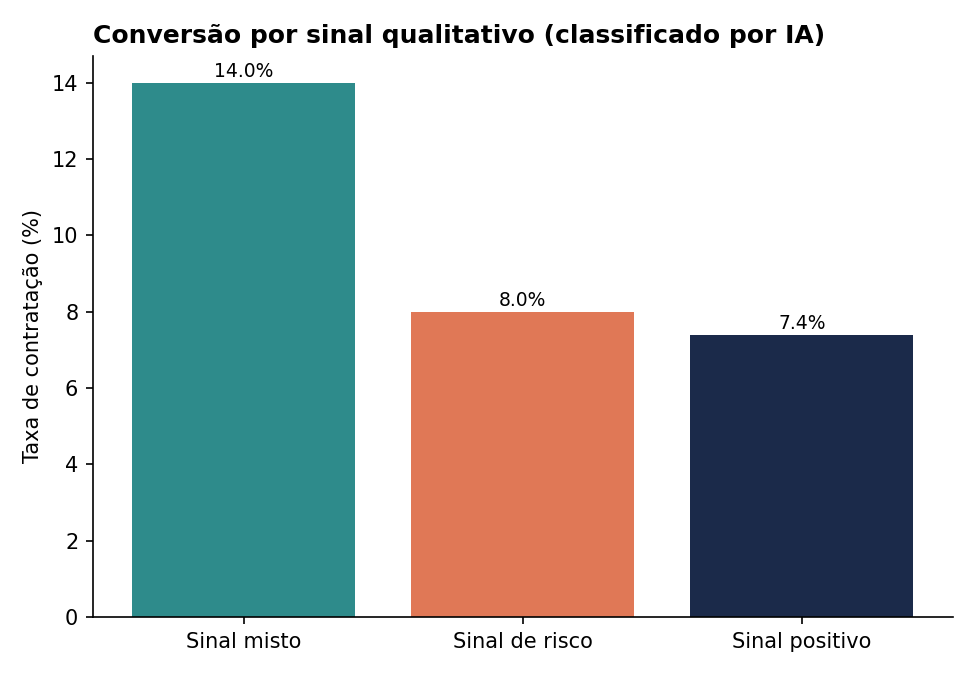

In [1]:
plt.imshow(plt.imread('../outputs/charts/05_sinal_ia.png')); plt.axis('off');

**Leitura honesta (e esse é o insight mais importante do notebook):** o sinal qualitativo classificado
por IA **não separa bem quem é contratado** — "sinal de risco" converte 8,0% e "sinal positivo" converte
7,4%, uma diferença dentro do ruído. "Sinal misto" (majoritariamente atrito salarial) converte mais
(14,0%), o que sugere que candidatos com objeção de salário **ainda fecham quando o resto do perfil é
forte** — não é um sinal de descarte automático.

Conclusão prática: **a nota qualitativa do recrutador, do jeito que está registrada hoje, tem baixo poder
preditivo** sobre contratação. Os sinais que realmente diferenciam são objetivos — score e velocidade de
resposta (seções 3-5). Isso não invalida o uso de IA no processo; pelo contrário, é o tipo de descoberta
que só aparece quando se testa o sinal em vez de assumir que "nota qualitativa boa = mais chance de
contratar". Recomendação: se o time quiser que as notas carreguem sinal preditivo, padronizar o registro
para capturar **motivo de recusa específico e estágio exato do atrito**, não só uma impressão geral.

## 7. Persist Score — quando vale insistir com um candidato ativo

In [1]:
active = df[df.final_stage.isin(["Sourced","Screening","Interview","Test","Offer"])].copy()
median_resp = df.response_time_days.median()

def persist_score(row):
    pts = 0
    if pd.notna(row.response_time_days) and row.response_time_days <= median_resp: pts += 1
    if pd.notna(row.technical_test_score) and row.technical_test_score >= 75: pts += 1
    if pd.notna(row.manager_score) and row.manager_score >= 75: pts += 1
    return pts

active["persist_score"] = active.apply(persist_score, axis=1)
active.persist_score.value_counts().sort_index()

{'0': 19, '1': 86, '2': 133, '3': 83, '4': 39}

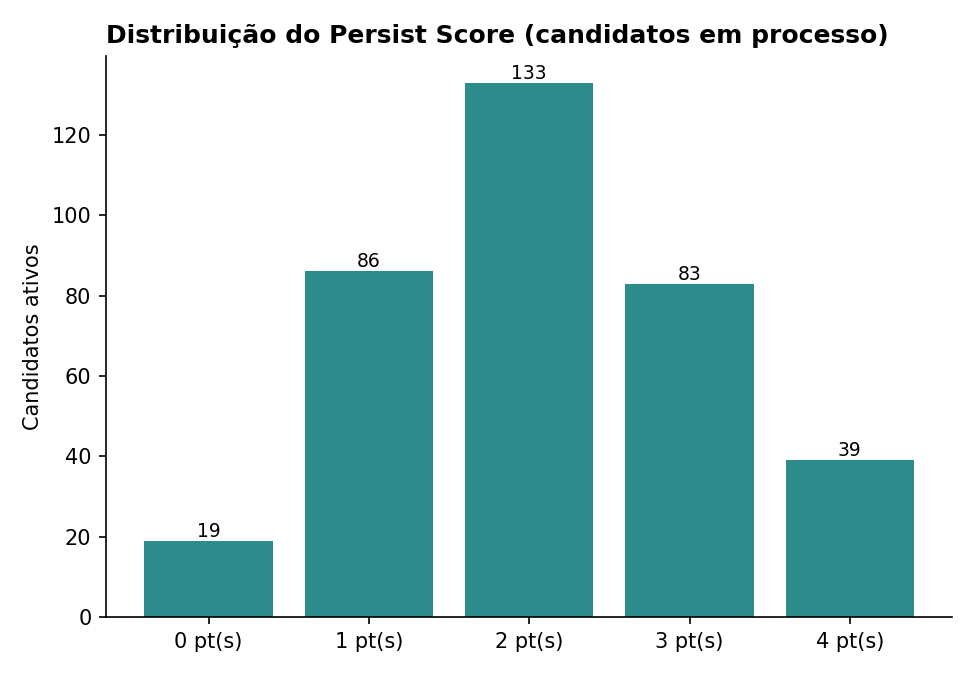

In [1]:
plt.imshow(plt.imread('../outputs/charts/06_persist_score.png')); plt.axis('off');

**Leitura:** o `persist_score` é deliberadamente simples e auditável (soma de 3 critérios objetivos:
resposta rápida, score técnico ≥75, score de gestor ≥75) — não um modelo caixa-preta. Candidatos com
score 3 (39 no funil atual) são o grupo de maior prioridade para follow-up ativo do recrutador; score 0-1
(105 candidatos) é onde vale reconsiderar tempo investido, salvo indicação forte de outro critério (ex.:
vaga com pool escasso).

**Nota metodológica importante:** as notas qualitativas do recrutador foram deliberadamente **excluídas**
deste score, porque a Seção 6 mostrou que elas não carregam sinal preditivo consistente hoje.

## 8. Síntese — respostas às perguntas do case

**Quais estratégias de sourcing convertem melhor?**
Github e Inbound convertem quase 2x mais que Indicação e Evento. Vale redistribuir esforço de sourcing
priorizando os canais de maior conversão, não só maior volume.

**Quais sinais indicam maior chance de avanço?**
Score técnico, comportamental e de gestor em conjunto (não isoladamente) e resposta rápida ao primeiro
contato. Notas qualitativas do recrutador, no formato atual, **não** são um sinal confiável.

**Quando vale insistir com um candidato?**
Quando o `persist_score` é 2-4 (resposta rápida + score forte). O funil já mostra que processos que vão
até a contratação demoram mais — insistir não é sinal de processo travado.

**Quando a conversão é baixa?**
No topo do funil: ~32% dos candidatos nunca respondem ao primeiro contato. O gargalo é engajamento
inicial, não qualificação técnica.

**Há padrões relevantes entre canais, recrutadores e perfis?**
Sim — e a variação entre recrutadores (3.9x) é maior que a variação entre canais. Isso
sugere que o maior ganho de conversão de curto prazo está em abrir espaço para troca de prática entre o
time (comunidade de prática, shadowing), não em mudar de canal.

Recomendações práticas e plano de ação completo estão em `docs/Relatorio_Tecnico.pdf`.